# Credit Card Fraud Detection — Data Preprocessing, Normalisation & Imbalance Framework

**CodSoft Data Science Internship — Task 5: Credit Card Fraud Detection**
(local folder `Task3_Credit_Card_Fraud_Detection`, my own project numbering)

**Phase 2 only.** This notebook builds and validates the preprocessing foundation the modelling
phases will stand on: a stratified train/test split, a scaling pipeline fitted on training data
alone, and a *framework* for handling class imbalance.

**No classifier is trained here.** No logistic regression, no random forest, no hyperparameter
tuning, no test-set metric, no persisted model. The resamplers below are constructed and their
effect on the training distribution is measured, but nothing is fitted to predict anything, and
the test set is not scored.

The raw CSV is checksummed at the start and again at the end to prove it was not touched.

---
## 1. Phase 2 Introduction

Phase 1 established what the data is. Its findings, which everything below builds on:

| Phase 1 finding | Consequence for Phase 2 |
|---|---|
| 284,807 rows × 31 columns, all numeric | no encoding step is needed |
| Zero missing values, zero infinities, no placeholders | **no imputer** — one would fit a statistic that is never used |
| 1,081 exact duplicate rows, none with conflicting labels | a decision is owed here — see section 2.2 |
| 492 frauds, 0.172749%, a 577.88:1 imbalance | the split **must** be stratified |
| `Time` spans 172,792 and `Amount` 25,691 against a `V1`–`V28` range of ~234 | scaling is required, and `Time`/`Amount` are the columns that force it |
| `V1`–`V28` are anonymised PCA components: zero-centred, std falling 1.9587 → 0.3301 | whether to standardise them is a genuine open question — see section 8 |
| IQR flags 48.62% of rows, incl. 96.95% of fraud | **outliers retained**; no capping or trimming anywhere |
| 10/10 leakage checks passed | six process commitments were recorded; this phase honours them |

### The six commitments Phase 1 made, and where each is kept

1. **Split first, fit afterwards on the training split alone** → sections 5 and 9
2. **Scalers live inside a `ColumnTransformer`/`Pipeline`** → section 9
3. **Resampling applies to the training fold only** → sections 10–11
4. **Tuning and threshold selection use CV on training data** → deferred to Phases 3–4
5. **The split is stratified on `Class`** → sections 5–6
6. **Duplicates are dropped before the split, if dropped at all** → section 2.2

---
## 2. Load the Phase 1 Dataset

### 2.1 Imports, configuration and the preprocessing module

All preprocessing logic lives in [`src/data_preprocessing.py`](../src/data_preprocessing.py)
rather than in this notebook. The notebook imports it, exercises it and validates it. That way
Phases 3–6 import the *same* definitions instead of re-deriving a split that might differ.

In [1]:
import hashlib
import platform
import sys
from pathlib import Path

import imblearn
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.3

# Same class colours as Phase 1, so a class means the same thing in every figure in the project.
C_LEGIT = "#3b5bdb"
C_FRAUD = "#e8590c"
CLASS_COLORS = {0: C_LEGIT, 1: C_FRAUD}
CLASS_LABELS = {0: "Legitimate (Class 0)", 1: "Fraudulent (Class 1)"}
# Neutral steps for comparisons that have no class dimension (before/after, strategy totals).
# Deliberately not the class colours, so nothing here reads as "legitimate" or "fraudulent".
C_NEUTRAL = "#495057"
C_BEFORE = "#868e96"
C_AFTER = "#212529"

print("python         ", sys.version.split()[0])
print("pandas         ", pd.__version__)
print("numpy          ", np.__version__)
print("matplotlib     ", matplotlib.__version__)
print("seaborn        ", sns.__version__)
print("scikit-learn   ", sklearn.__version__)
print("imbalanced-learn", imblearn.__version__)
print("platform       ", platform.system(), platform.release())

python          3.13.0
pandas          3.0.6
numpy           2.5.3
matplotlib      3.11.2
seaborn         0.13.2
scikit-learn    1.9.1
imbalanced-learn 0.14.2
platform        Windows 11


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp

print("project directory :", PROJECT_DIR.name)
print("preprocessing module:", Path(dp.__file__).relative_to(PROJECT_DIR).as_posix())
print("dataset            :", dp.default_dataset_path().relative_to(PROJECT_DIR).as_posix())
print()
print("RANDOM_STATE :", dp.RANDOM_STATE)
print("TEST_SIZE    :", dp.TEST_SIZE)

project directory : Task3_Credit_Card_Fraud_Detection
preprocessing module: src/data_preprocessing.py
dataset            : dataset/creditcard.csv

RANDOM_STATE : 42
TEST_SIZE    : 0.2


### Raw-file fingerprint, taken *before* anything is read

The digest is recorded now and re-checked in section 14. The module also refuses to load a file
whose digest does not match the Phase 1 value, so a swapped or corrupted dataset fails loudly
rather than quietly changing every number downstream.

In [3]:
DATASET_PATH = dp.default_dataset_path()
FILE_SIZE_BYTES = DATASET_PATH.stat().st_size
SHA256_INITIAL = dp.sha256_of_file(DATASET_PATH)

print("file          :", DATASET_PATH.name)
print("size (bytes)  :", f"{FILE_SIZE_BYTES:,}")
print("SHA-256       :", SHA256_INITIAL)
print()
print("matches the digest recorded in Phase 1:", SHA256_INITIAL == dp.RAW_DATASET_SHA256)

file          : creditcard.csv
size (bytes)  : 150,828,752
SHA-256       : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89

matches the digest recorded in Phase 1: True


### Load and validate

`dp.load_data()` verifies the checksum, reads the CSV, then validates the frame against the
layout Phase 1 established — column names *and order*, row count, dtypes, no missing values, no
infinities, binary target. Any mismatch raises.

In [4]:
df_raw = dp.load_data(drop_duplicates=False)

print("raw frame loaded and validated")
print("shape   :", df_raw.shape)
print("columns :", list(df_raw.columns)[:4], "...", list(df_raw.columns)[-3:])
print("dtypes  :", df_raw.dtypes.value_counts().to_dict())
print("target  :", dp.TARGET_COLUMN)
print()
print("class counts:", df_raw[dp.TARGET_COLUMN].value_counts().sort_index().to_dict())
df_raw.head(3)

raw frame loaded and validated
shape   : (284807, 31)
columns : ['Time', 'V1', 'V2', 'V3'] ... ['V28', 'Amount', 'Class']
dtypes  : {dtype('float64'): 30, dtype('int64'): 1}
target  : Class

class counts: {0: 284315, 1: 492}


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


### 2.2 The duplicate decision Phase 1 deferred

Phase 1 found 1,081 exact duplicate rows and deliberately left the decision to this phase. Here
is the decision and the reasoning, recorded in the module itself as `dp.DUPLICATE_DECISION` so
it travels with the code rather than living only in a notebook:

In [5]:
print(dp.DUPLICATE_DECISION)

The 1,081 exact duplicate rows found in Phase 1 (1,062 legitimate, 19 fraudulent) are dropped
before the train/test split, keeping the first occurrence of each.

The reason is not that duplicates are dirty. Phase 1 established that they carry no conflicting
labels and are plausible collisions of small transactions in a finite-precision PCA space. The
reason is split contamination: an identical row appearing in both the training and the test set
means the model is scored on a row it has already memorised, which inflates the test result
without any corresponding gain in real performance. Dropping them before the split removes that
possibility entirely.

Dropping after the split would not work - it would leave the copies that had already crossed the
boundary. Hence: deduplicate, then split.



In [6]:
extra_copies = df_raw.duplicated(keep="first")
dropped_by_class = df_raw.loc[extra_copies, dp.TARGET_COLUMN].value_counts().sort_index()

print(f"rows before deduplication : {len(df_raw):,}")
print(f"extra copies dropped      : {int(extra_copies.sum()):,}")
print(f"  legitimate              : {int(dropped_by_class.get(0, 0)):,}")
print(f"  fraudulent              : {int(dropped_by_class.get(1, 0)):,}")
print()

df = dp.load_data(drop_duplicates=True)

print(f"rows after deduplication  : {len(df):,}")
print(f"rows removed              : {len(df_raw) - len(df):,}")
print()
counts_full = df[dp.TARGET_COLUMN].value_counts().sort_index()
print(f"legitimate : {int(counts_full[0]):,}  ({counts_full[0] / len(df) * 100:.6f}%)")
print(f"fraudulent : {int(counts_full[1]):,}      ({counts_full[1] / len(df) * 100:.6f}%)")
print(f"imbalance  : {counts_full[0] / counts_full[1]:.4f} : 1")

rows before deduplication : 284,807
extra copies dropped      : 1,081
  legitimate              : 1,062
  fraudulent              : 19



rows after deduplication  : 283,726
rows removed              : 1,081

legitimate : 283,253  (99.833290%)
fraudulent : 473      (0.166710%)
imbalance  : 598.8436 : 1


Deduplication costs 19 of the 492 fraudulent rows and pushes the imbalance slightly further,
from 577.88:1 to **598.84:1**. That is the price of the decision and it is worth stating rather
than glossing over: the minority class is now 473 examples, not 492.

It is still the right trade. Those 19 rows were byte-identical copies of frauds that remain in
the data; keeping them would not have taught a model anything new, but letting a copy sit in the
test set while its twin sits in the training set would have made the test score partly a
measurement of memorisation. A slightly harder honest problem beats an easier dishonest one.

**The raw CSV is untouched.** `df` is a new in-memory frame; `dataset/creditcard.csv` still has
all 284,807 rows, which section 14 re-confirms by checksum.

---
## 3. Preprocessing Objectives

| # | Objective | Why it is needed | Status |
|---|---|---|---|
| 1 | Separate features from target | `Class` must never enter `X` | section 4 |
| 2 | Stratified train/test split | a 0.17% positive rate makes an unstratified draw a lottery | section 5 |
| 3 | Scale `Time` and `Amount` | they span 737× and 110× the component range | sections 7–9 |
| 4 | Decide on `V1`–`V28` scaling | genuinely open; two defensible answers | section 8 |
| 5 | Fit every statistic on train only | the core leakage guarantee | sections 9, 13 |
| 6 | A reusable, importable pipeline | Phases 3–6 must see the identical transformation | `src/data_preprocessing.py` |
| 7 | A **safe** imbalance framework | resampling must never reach validation or test data | sections 10–11 |
| 8 | Preserve the test distribution | the test set must look like reality, not like a balanced sample | sections 11–12 |

### Explicitly out of scope for this phase

No classifier is fitted. No metric is computed. No model is selected, tuned or persisted. No
prediction API or dashboard is built. Where this notebook constructs a resampler, it does so to
*measure how the training distribution changes*, not to judge whether that change is good — that
judgement requires a model and belongs to Phase 4.

---
## 4. Feature / Target Separation

The feature list is taken from the dataset's own columns rather than hard-coded, then checked
against the expected layout. `Class` is selected out by name, and `split_features_target` raises
if it ever appears in `X`.

In [7]:
X_all, y_all = dp.split_features_target(df)

print("target  y :", dp.TARGET_COLUMN, "|", y_all.shape, "|", y_all.dtype)
print("features X:", X_all.shape)
print()
print("feature columns (30):")
print(" ", list(X_all.columns))
print()
print("'Class' present in X          :", dp.TARGET_COLUMN in X_all.columns)
print("X and y row counts match      :", len(X_all) == len(y_all))
print("feature list matches expected :", list(X_all.columns) == dp.FEATURE_COLUMNS)
print()
print("column groups used by the pipeline:")
print(f"  Time      : {[dp.TIME_COLUMN]}")
print(f"  components: {dp.COMPONENT_COLUMNS[0]} .. {dp.COMPONENT_COLUMNS[-1]}  ({len(dp.COMPONENT_COLUMNS)} columns)")
print(f"  Amount    : {[dp.AMOUNT_COLUMN]}")

target  y : Class | (283726,) | int64
features X: (283726, 30)

feature columns (30):
  ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

'Class' present in X          : False
X and y row counts match      : True
feature list matches expected : True

column groups used by the pipeline:
  Time      : ['Time']
  components: V1 .. V28  (28 columns)
  Amount    : ['Amount']


No feature is derived from the target and no new feature is created at all. The 30 predictors
that enter the pipeline are the 30 columns the file ships with.

---
## 5. Train / Test Split

**80 / 20, stratified on `Class`, `random_state=42`.** Phase 1 documented no reason to depart
from the standard split, and with 473 positives an 80/20 draw leaves ~95 frauds in the test set
— few, but enough for a precision/recall estimate to mean something. A smaller test fraction
would make those metrics too noisy to act on; a larger one would starve training of the minority
class.

In [8]:
split = dp.split_data(df, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)

X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test

print(f"total rows : {len(df):,}")
print(f"train rows : {split.n_train:,}  ({split.n_train / len(df) * 100:.2f}%)")
print(f"test rows  : {split.n_test:,}   ({split.n_test / len(df) * 100:.2f}%)")
print()
print("random_state :", dp.RANDOM_STATE)
print("stratify     : y (Class)")
print("shuffle      : True")

total rows : 283,726
train rows : 226,980  (80.00%)
test rows  : 56,746   (20.00%)

random_state : 42
stratify     : y (Class)
shuffle      : True


In [9]:
split_table = split.class_counts()
split_table.loc["full dataset"] = {
    "rows": len(df),
    "legitimate": int(counts_full[0]),
    "fraudulent": int(counts_full[1]),
    "fraud_%": counts_full[1] / len(df) * 100,
    "ratio_0_to_1": counts_full[0] / counts_full[1],
}
split_table = split_table.loc[["full dataset", "train", "test"]]
split_table[["rows", "legitimate", "fraudulent"]] = split_table[["rows", "legitimate", "fraudulent"]].astype(int)
split_table

,rows,legitimate,fraudulent,fraud_%,ratio_0_to_1
full dataset,283726,283253,473,0.1667,598.8436
train,226980,226602,378,0.1665,599.4762
test,56746,56651,95,0.1674,596.3263


In [10]:
for name, y_split in (("train", y_train), ("test", y_test)):
    counts = y_split.value_counts().sort_index()
    print(f"{name}:")
    print(f"  rows              : {len(y_split):,}")
    print(f"  legitimate (0)    : {int(counts[0]):,}  ({counts[0] / len(y_split) * 100:.6f}%)")
    print(f"  fraudulent (1)    : {int(counts[1]):,}      ({counts[1] / len(y_split) * 100:.6f}%)")
    print(f"  imbalance ratio   : {counts[0] / counts[1]:.4f} : 1")
    print()

train:
  rows              : 226,980
  legitimate (0)    : 226,602  (99.833466%)
  fraudulent (1)    : 378      (0.166534%)
  imbalance ratio   : 599.4762 : 1

test:
  rows              : 56,746
  legitimate (0)    : 56,651  (99.832587%)
  fraudulent (1)    : 95      (0.167413%)
  imbalance ratio   : 596.3263 : 1



---
## 6. Stratification Validation

Stratification is the whole reason the split is trustworthy, so it is measured rather than
assumed. The comparison below is against the **full dataset** fraud rate, in percentage points.

In [11]:
full_rate = float((y_all == 1).mean() * 100)
train_rate = float((y_train == 1).mean() * 100)
test_rate = float((y_test == 1).mean() * 100)

print(f"fraud rate, full dataset : {full_rate:.6f}%")
print(f"fraud rate, train        : {train_rate:.6f}%   (difference {train_rate - full_rate:+.6f} pp)")
print(f"fraud rate, test         : {test_rate:.6f}%   (difference {test_rate - full_rate:+.6f} pp)")
print()
print(f"largest deviation        : {max(abs(train_rate - full_rate), abs(test_rate - full_rate)):.6f} pp")

fraud rate, full dataset : 0.166710%
fraud rate, train        : 0.166534%   (difference -0.000176 pp)
fraud rate, test         : 0.167413%   (difference +0.000703 pp)

largest deviation        : 0.000703 pp


Both splits sit within ~0.001 pp of the full rate. For contrast, here is what an **unstratified**
split of the same data would have produced — the thing Phase 1 warned against. This is run purely
to demonstrate the risk; the unstratified split is discarded immediately and never used.

In [12]:
from sklearn.model_selection import train_test_split as _tts

print("unstratified draws of the same 80/20 split, varying only the seed:")
print(f"{'seed':>6} {'test frauds':>12} {'test fraud %':>14} {'deviation (pp)':>16}")
for seed in (0, 1, 7, 42, 2024):
    _, _, _, y_test_u = _tts(X_all, y_all, test_size=dp.TEST_SIZE, random_state=seed, stratify=None)
    rate_u = float((y_test_u == 1).mean() * 100)
    print(f"{seed:>6} {int((y_test_u == 1).sum()):>12} {rate_u:>13.6f}% {rate_u - full_rate:>+15.6f}")

print()
print(f"stratified (seed {dp.RANDOM_STATE}):  {int((y_test == 1).sum()):>7} frauds, "
      f"{test_rate:.6f}%, deviation {test_rate - full_rate:+.6f} pp")
print()
print("The unstratified fraud count swings by tens of transactions from seed to seed. With only")
print("95 positives expected in the test set, that swing moves recall by several points for")
print("reasons that have nothing to do with the model. Stratification removes that noise source.")

unstratified draws of the same 80/20 split, varying only the seed:
  seed  test frauds   test fraud %   deviation (pp)
     0           87      0.153315%       -0.013395


     1           87      0.153315%       -0.013395


     7           90      0.158601%       -0.008109


    42           90      0.158601%       -0.008109
  2024          102      0.179748%       +0.013038

stratified (seed 42):       95 frauds, 0.167413%, deviation +0.000703 pp

The unstratified fraud count swings by tens of transactions from seed to seed. With only
95 positives expected in the test set, that swing moves recall by several points for
reasons that have nothing to do with the model. Stratification removes that noise source.


### Visualisation 8 — class distribution across full dataset, train and test

Percentages rather than raw counts, because the three groups have very different sizes: the point
is that the *proportion* survives the split, which raw counts would obscure.

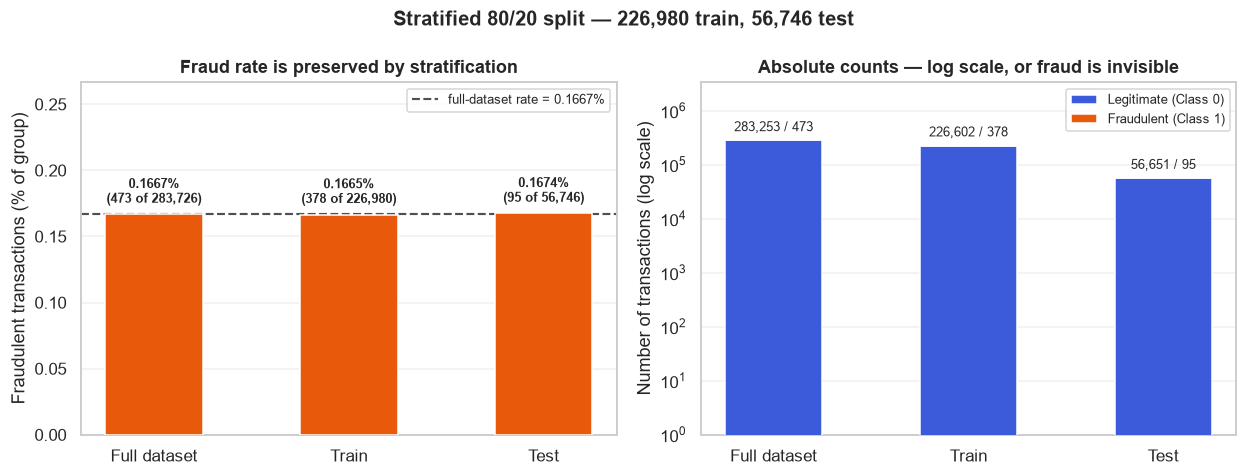

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

groups = ["Full dataset", "Train", "Test"]
legit_counts = [int(counts_full[0]), int((y_train == 0).sum()), int((y_test == 0).sum())]
fraud_counts = [int(counts_full[1]), int((y_train == 1).sum()), int((y_test == 1).sum())]
totals = [a + b for a, b in zip(legit_counts, fraud_counts)]

x = np.arange(len(groups))
bars = axes[0].bar(x, [f / t * 100 for f, t in zip(fraud_counts, totals)],
                   color=C_FRAUD, width=0.5, zorder=3)
axes[0].axhline(full_rate, color=C_NEUTRAL, linestyle="--", linewidth=1.4,
                label=f"full-dataset rate = {full_rate:.4f}%")
axes[0].set_xticks(x, groups)
axes[0].set_ylabel("Fraudulent transactions (% of group)")
axes[0].set_title("Fraud rate is preserved by stratification")
axes[0].set_ylim(0, full_rate * 1.6)
axes[0].legend(frameon=True, loc="upper right", fontsize=8.5)
for bar, f, t in zip(bars, fraud_counts, totals):
    axes[0].annotate(f"{f / t * 100:.4f}%\n({f:,} of {t:,})",
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha="center", va="bottom", fontsize=8.5, fontweight="bold")
axes[0].grid(axis="x", visible=False)

axes[1].bar(x, legit_counts, color=C_LEGIT, width=0.5, zorder=3, label=CLASS_LABELS[0])
axes[1].bar(x, fraud_counts, bottom=legit_counts, color=C_FRAUD, width=0.5, zorder=3,
            label=CLASS_LABELS[1])
axes[1].set_yscale("log")
axes[1].set_xticks(x, groups)
axes[1].set_ylabel("Number of transactions (log scale)")
axes[1].set_title("Absolute counts — log scale, or fraud is invisible")
axes[1].legend(frameon=True, loc="upper right", fontsize=8.5)
for i, (l, f) in enumerate(zip(legit_counts, fraud_counts)):
    axes[1].annotate(f"{l:,} / {f:,}", xy=(i, l + f), xytext=(0, 6),
                     textcoords="offset points", ha="center", fontsize=8.5)
axes[1].set_ylim(1, max(totals) * 12)
axes[1].grid(axis="x", visible=False)

fig.suptitle(f"Stratified 80/20 split — {split.n_train:,} train, {split.n_test:,} test",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "08_train_test_class_distribution.png")
plt.show()

---
## 7. Feature Scale Analysis

Re-measured **on the training split only**. Phase 1 measured the full dataset, which was correct
for an audit but is not what a preprocessing decision may be based on: using full-dataset
statistics to choose a transformation is a mild form of leakage, and it costs nothing to avoid.

In [14]:
train_scale = pd.DataFrame({
    "min": X_train.min(),
    "max": X_train.max(),
    "range": X_train.max() - X_train.min(),
    "mean": X_train.mean(),
    "std": X_train.std(),
})
train_scale.index.name = "feature"

component_range = float(X_train[dp.COMPONENT_COLUMNS].to_numpy().max()
                        - X_train[dp.COMPONENT_COLUMNS].to_numpy().min())

group_summary = pd.DataFrame([
    {"feature group": "Time (seconds)", "columns": 1,
     "min": train_scale.loc["Time", "min"], "max": train_scale.loc["Time", "max"],
     "range": train_scale.loc["Time", "range"], "mean": train_scale.loc["Time", "mean"],
     "std": train_scale.loc["Time", "std"]},
    {"feature group": "Amount (currency)", "columns": 1,
     "min": train_scale.loc["Amount", "min"], "max": train_scale.loc["Amount", "max"],
     "range": train_scale.loc["Amount", "range"], "mean": train_scale.loc["Amount", "mean"],
     "std": train_scale.loc["Amount", "std"]},
    {"feature group": "V1-V28 (PCA components)", "columns": 28,
     "min": X_train[dp.COMPONENT_COLUMNS].to_numpy().min(),
     "max": X_train[dp.COMPONENT_COLUMNS].to_numpy().max(),
     "range": component_range,
     "mean": X_train[dp.COMPONENT_COLUMNS].to_numpy().mean(),
     "std": X_train[dp.COMPONENT_COLUMNS].to_numpy().std()},
]).set_index("feature group")

group_summary.round(4)

,columns,min,max,range,mean,std
feature group,,,,,,
Time (seconds),1,0.0000,"172,792.0000","172,792.0000","94,900.2244","47,488.2143"
Amount (currency),1,0.0000,"19,656.5300","19,656.5300",88.3871,245.7670
V1-V28 (PCA components),28,-73.2167,39.4209,112.6376,0.0002,1.0401


In [15]:
print(f"component range (V1-V28)        : {component_range:,.2f}")
print(f"Time range / component range    : {train_scale.loc['Time', 'range'] / component_range:,.0f}x")
print(f"Amount range / component range  : {train_scale.loc['Amount', 'range'] / component_range:,.0f}x")
print()
comp_std = X_train[dp.COMPONENT_COLUMNS].std()
print(f"component std, largest (V1)     : {comp_std.max():.4f}")
print(f"component std, smallest (V28)   : {comp_std.min():.4f}")
print(f"spread within the components    : {comp_std.max() / comp_std.min():.2f}x")
print(f"components are zero-centred     : largest |mean| = {X_train[dp.COMPONENT_COLUMNS].mean().abs().max():.4f}")

component range (V1-V28)        : 112.64
Time range / component range    : 1,534x
Amount range / component range  : 175x

component std, largest (V1)     : 1.9473
component std, smallest (V28)   : 0.3257
spread within the components    : 5.98x
components are zero-centred     : largest |mean| = 0.0055


---
## 8. Scaling Strategy

### 8.1 What is not a judgement call

Measured on the training split (section 7): `Time` spans **1,534×** and `Amount` **175×** the
component range. Those multiples are larger than the 737× and 110× Phase 1 reported on the full
dataset, for a mundane reason — the two rows holding the most extreme component values (`V5` at
−113.74 and `V7` at +120.59) happen to sit in the test split, so the training component range is
112.64 rather than 234.33. The conclusion is unaffected and only gets stronger.

For logistic regression —
the model the CodSoft brief names first — the coefficients are fitted against an L2 penalty that
treats every coefficient the same, and gradient descent on wildly different scales converges
badly or not at all. **`Time` and `Amount` must be scaled.** Every strategy below does it.

### 8.2 What genuinely is a judgement call: `V1`–`V28`

The components are already zero-centred, but they are **not** unit-variance: on the training
split their standard deviations fall monotonically from **1.9473** (`V1`) to **0.3257** (`V28`),
a spread of about **6.0×**. Two defensible readings, and the data alone cannot settle it:

| Leave them unscaled | Standardise them |
|---|---|
| The 5.9× spread *is* the PCA variance ordering — real information about how much of the original data each component carries | L2 regularisation penalises all coefficients equally, so a low-variance component needs a larger coefficient for the same effect and is penalised harder for it |
| 5.9× is small next to the 737× mismatch that actually needed fixing | That penalty asymmetry is an artefact of the units, not a property of the data |
| Preserves the geometry SMOTE interpolates through | Puts every feature on equal footing before distance-based resampling |

**Resolution.** Both are implemented. `"standard"` is the **default**, because regularised
logistic regression is the primary planned model and uniform treatment under the penalty is the
safer default there. Tree-based models are scale-invariant and are unaffected either way. The
empirical choice between them is deferred to **Phase 3, by cross-validation on the training split
only** — never by peeking at the test set.

### 8.3 A third candidate: `log1p(Amount)`

Phase 1 measured `Amount` skewness at **16.98**. Standardising recentres it but leaves that shape
untouched, so the scaled column still has a long one-sided tail. `log1p` addresses the shape, and
it is safe here because Phase 1 confirmed `Amount ≥ 0` with no negative values. Implemented as
`"log_amount"` and likewise deferred to the Phase 3 comparison.

A `RobustScaler` would be a fourth reasonable candidate given the heavy tails. It is deliberately
left out to keep the Phase 3 comparison small enough to be meaningful.

In [16]:
print(dp.build_preprocessor.__doc__)

Build the (unfitted) preprocessing transformer.

**What needs scaling, and why it is not "all of it by reflex".**

Phase 1 measured the scales directly. ``Time`` spans 172,792 and ``Amount`` spans 25,691,
against a total ``V1``-``V28`` range of about 234 - roughly 737x and 110x the component
range respectively. For any gradient- or distance-based model those two columns would
dominate the objective through magnitude alone. **Scaling ``Time`` and ``Amount`` is
therefore not a judgement call; it is required, and every strategy below does it.**

The genuinely open question is ``V1``-``V28``. They are already centred on zero, but they
are *not* unit-variance: their standard deviations fall monotonically from 1.9587 (``V1``)
to 0.3301 (``V28``), a spread of about 5.9x. Two defensible readings:

* *Leave them.* That 5.9x spread is the PCA variance ordering and is real information about
  how much of the original data each component captures. It is also small next to the 737x
  mismatch that 

---
## 9. Preprocessing Pipeline

### The order, and why it is not negotiable

```
RAW DATA (284,807 rows, read-only)
      |
      +--> drop exact duplicates            (before the split, or copies cross the boundary)
      |
      +--> STRATIFIED TRAIN / TEST SPLIT    <-- everything below sees only one side at a time
      |
      +--> FIT preprocessing on X_train ONLY
      |
      +--> TRANSFORM X_train
      |
      +--> TRANSFORM X_test                 (transform only - never fit)
      |
      +--> OPTIONAL RESAMPLING of the TRAINING data only
      |
      +--> MODEL TRAINING                   (Phase 3 - not in this notebook)
```

Every arrow that points *into* the test set is a `transform`. None is a `fit`. The moment a
scaler's mean or standard deviation is computed from rows that later appear in the test set, the
test score stops being an estimate of performance on unseen data.

In [17]:
preprocessor = dp.build_preprocessor("standard")
print(preprocessor)

ColumnTransformer(transformers=[('scale_all', StandardScaler(),
                                 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
                                  'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13',
                                  'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
                                  'V20', 'V21', 'V22', 'V23', 'V24', 'V25',
                                  'V26', 'V27', 'V28', 'Amount'])],
                  verbose_feature_names_out=False)


In [18]:
# FIT ON TRAINING DATA ONLY. X_test is not passed to fit, anywhere, at any point.
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)   # transform only

feature_names_out = dp.get_feature_names(preprocessor)

print("fitted on      :", f"{len(X_train):,} training rows")
print()
print("X_train :", X_train.shape, "->", X_train_t.shape)
print("X_test  :", X_test.shape, "->", X_test_t.shape)
print()
print("input features  :", len(dp.FEATURE_COLUMNS))
print("output features :", len(feature_names_out))
print("output order    :", feature_names_out[:4], "...", feature_names_out[-2:])
print()
print("feature count unchanged (no expansion, no encoding):",
      len(feature_names_out) == len(dp.FEATURE_COLUMNS))

fitted on      : 226,980 training rows

X_train : (226980, 30) -> (226980, 30)
X_test  : (56746, 30) -> (56746, 30)

input features  : 30
output features : 30
output order    : ['Time', 'V1', 'V2', 'V3'] ... ['V28', 'Amount']

feature count unchanged (no expansion, no encoding): True


### 9.1 Scaling validation — transformed statistics

After a `StandardScaler` fitted on the training split:

* **training** columns should have mean ≈ 0 and std ≈ 1 — that is what the scaler solved for;
* **test** columns should be *close to* but **not exactly** 0 and 1. If the test columns came out
  at exactly 0 and 1, the scaler would have been fitted on them, which is precisely the bug this
  section exists to rule out.

In [19]:
train_t_df = pd.DataFrame(X_train_t, columns=feature_names_out)
test_t_df = pd.DataFrame(X_test_t, columns=feature_names_out)

comparison = pd.DataFrame({
    "train mean": train_t_df.mean(),
    "train std": train_t_df.std(),
    "test mean": test_t_df.mean(),
    "test std": test_t_df.std(),
})
comparison.index.name = "feature"
print("transformed feature statistics (first 6 and last 3 columns):")
pd.concat([comparison.head(6), comparison.tail(3)]).round(6)

transformed feature statistics (first 6 and last 3 columns):


,train mean,train std,test mean,test std
feature,,,,
Time,-0.0000,1.0000,-0.0094,0.9992
V1,0.0000,1.0000,0.0023,1.0019
V2,-0.0000,1.0000,0.0043,0.9911
V3,0.0000,1.0000,-0.0017,1.0047
V4,-0.0000,1.0000,-0.0033,0.9902
V5,0.0000,1.0000,-0.0114,1.0623
V27,0.0000,1.0000,0.0010,1.0645
V28,0.0000,1.0000,-0.0061,1.0345
Amount,0.0000,1.0000,0.0017,1.0910


In [20]:
print(f"training means  — largest |mean| : {train_t_df.mean().abs().max():.2e}   (should be ~0)")
print(f"training stds   — range          : {train_t_df.std().min():.6f} to {train_t_df.std().max():.6f}   (should be ~1)")
print()
print(f"test means      — largest |mean| : {test_t_df.mean().abs().max():.6f}   (close to 0, not exactly)")
print(f"test stds       — range          : {test_t_df.std().min():.6f} to {test_t_df.std().max():.6f}")
print()
print("Test statistics are near - but not equal to - 0 and 1. That gap is the evidence that the")
print("scaler was fitted on the training rows and merely applied to the test rows.")

training means  — largest |mean| : 1.52e-16   (should be ~0)


training stds   — range          : 1.000002 to 1.000002   (should be ~1)

test means      — largest |mean| : 0.011449   (close to 0, not exactly)
test stds       — range          : 0.983941 to 1.109790

Test statistics are near - but not equal to - 0 and 1. That gap is the evidence that the
scaler was fitted on the training rows and merely applied to the test rows.


---
## 10. Class-Imbalance Strategy

The training split holds **378 fraudulent** rows against **226,602 legitimate** — a 599.48:1
ratio. Five candidate approaches are documented here and made available through
`dp.build_resampler`. **None is applied to any data that will be used for evaluation, and none is
judged in this phase.**

| | Strategy | What it does to the training rows | Cost |
|---|---|---|---|
| **A** | **No resampling** | nothing — original distribution | the model sees fraud 0.17% of the time and can trivially ignore it |
| **B** | **Class weights** | nothing — reweights the *loss*, not the rows | no data invented or discarded; a classifier argument, applied in Phase 3 |
| **C** | **Random oversampling** | duplicates existing minority rows | the same 378 frauds repeated ~600× each; strong overfitting risk |
| **D** | **SMOTE** | interpolates new minority points between neighbours | synthetic rows that never occurred; can blur the class boundary |
| **E** | **Random undersampling** | discards majority rows | throws away ~226,000 legitimate transactions, i.e. almost all the data |

Note that **A and B change no rows at all** — `dp.build_resampler` returns `None` for both, which
is why class weighting is a Phase 3 classifier argument rather than a preprocessing step here.

### 10.1 The evaluation principle, recorded now so it is not rationalised later

> **A strategy is not better because it produces a 50/50 training set.**

Every resampler below produces a perfectly balanced training set. That tells us nothing about
which one helps. Balance is a property of the *training input*, not evidence about output
quality. The comparison that decides anything happens in Phase 4, judged on:

**Precision · Recall · F1-score · confusion matrix · PR-AUC · ROC-AUC where appropriate**

and never on accuracy, which Phase 1 showed sits at 99.83% for a model that catches no fraud at
all. Undersampling in particular will produce a *lovely* balanced training set out of 756 rows
while discarding 99.7% of the legitimate data — the balance is real and the loss of information
is also real.

In [21]:
print("resampler objects returned by dp.build_resampler (constructed, not applied):")
for strategy in ("none", "class_weight", "oversample", "smote", "undersample"):
    sampler = dp.build_resampler(strategy, random_state=dp.RANDOM_STATE)
    described = type(sampler).__name__ if sampler is not None else "None (changes no rows)"
    print(f"  {strategy:<13} -> {described}")

resampler objects returned by dp.build_resampler (constructed, not applied):
  none          -> None (changes no rows)
  class_weight  -> None (changes no rows)
  oversample    -> RandomOverSampler
  smote         -> SMOTE
  undersample   -> RandomUnderSampler


---
## 11. Training-Only Resampling Validation

Each resampler is now applied **to the training split only**, to measure how it changes the
training distribution. The test set is deliberately passed nowhere near any of them, and section
11.2 proves it came out the other side identical.

`random_state=42` throughout, so these counts are reproducible.

In [22]:
# Snapshot the test set BEFORE any resampling exists, so section 11.2 can compare against it.
y_test_before = y_test.copy()
test_counts_before = y_test_before.value_counts().sort_index()
n_test_before = len(y_test_before)

train_counts = y_train.value_counts().sort_index()
resampling_rows = [{
    "strategy": "A - original (no resampling)",
    "training rows": len(y_train),
    "class 0": int(train_counts[0]),
    "class 1": int(train_counts[1]),
    "minority %": train_counts[1] / len(y_train) * 100,
    "ratio 0:1": train_counts[0] / train_counts[1],
}]

resampled_targets = {"A - original (no resampling)": y_train}

for label, strategy in (
    ("C - random oversampling", "oversample"),
    ("D - SMOTE", "smote"),
    ("E - random undersampling", "undersample"),
):
    sampler = dp.build_resampler(strategy, random_state=dp.RANDOM_STATE)
    # Fitted on the TRAINING split only. X_test / y_test are not arguments here.
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    counts = pd.Series(y_res).value_counts().sort_index()
    resampled_targets[label] = pd.Series(y_res)
    resampling_rows.append({
        "strategy": label,
        "training rows": len(y_res),
        "class 0": int(counts[0]),
        "class 1": int(counts[1]),
        "minority %": counts[1] / len(y_res) * 100,
        "ratio 0:1": counts[0] / counts[1],
    })

resampling_table = pd.DataFrame(resampling_rows).set_index("strategy")
resampling_table

,training rows,class 0,class 1,minority %,ratio 0:1
strategy,,,,,
A - original (no resampling),226980,226602,378,0.1665,599.4762
C - random oversampling,453204,226602,226602,50.0000,1.0000
D - SMOTE,453204,226602,226602,50.0000,1.0000
E - random undersampling,756,378,378,50.0000,1.0000


Strategy **B (class weights)** is absent from that table on purpose: it changes no rows, so it has
no row count to report. It reweights the loss function inside the classifier, which is a Phase 3
concern.

Reading the table honestly:

* **Oversampling and SMOTE** both take the training set from 226,980 to 453,204 rows — a 2.0×
  increase, entirely minority rows. Oversampling reaches 226,602 fraud rows by repeating the same
  378 about 600 times each; SMOTE reaches the same count by interpolating new points. Same shape,
  very different content.
* **Undersampling** collapses 226,980 rows to **756** — it discards 226,224 legitimate
  transactions, 99.83% of the majority class, to reach balance.

None of these numbers says which approach works. They say what each approach costs.

### 11.1 How resampling will actually be used: inside an imblearn pipeline

Applying a resampler by hand as above is fine for *measuring* the distribution change. It is the
wrong way to use one for modelling, because hand-resampling before cross-validation puts
duplicated or interpolated copies of the same fraud into both the training and the validation
fold, and the reported recall becomes fiction.

The fix is structural: put the sampler inside an `imblearn.pipeline.Pipeline`, which applies its
samplers during `fit` only and skips them entirely during `predict`/`score`. Under
cross-validation each training fold is then resampled independently and no validation fold ever
sees a synthetic row.

The pipeline below is built and inspected to prove the architecture works. **Its classifier slot
is left empty — that is Phase 3's to fill.**

In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline

# The architecture Phases 3-4 will use. No classifier step: Phase 2 does not train models.
modelling_pipeline_skeleton = ImbPipeline([
    ("preprocess", dp.build_preprocessor("standard")),
    ("resample", dp.build_resampler("smote", random_state=dp.RANDOM_STATE)),
    # ("classifier", <-- Phase 3 appends the estimator here),
])

print("pipeline steps:")
for name, step in modelling_pipeline_skeleton.steps:
    print(f"  {name:<11} -> {type(step).__name__}")
print()
print("classifier step present:", any(n == "classifier" for n, _ in modelling_pipeline_skeleton.steps))
print()
print("Order matters: preprocessing is fitted on the training fold, then SMOTE interpolates in")
print("the scaled space. Resampling before scaling would let synthetic rows influence the")
print("scaler's mean and standard deviation.")

pipeline steps:
  preprocess  -> ColumnTransformer
  resample    -> SMOTE

classifier step present: False

Order matters: preprocessing is fitted on the training fold, then SMOTE interpolates in
the scaled space. Resampling before scaling would let synthetic rows influence the
scaler's mean and standard deviation.


### 11.2 Proof that the test set was never touched

In [24]:
test_counts_after = y_test.value_counts().sort_index()

print("test set, before any resampling existed:")
print(f"  rows       : {n_test_before:,}")
print(f"  legitimate : {int(test_counts_before[0]):,}")
print(f"  fraudulent : {int(test_counts_before[1]):,}")
print(f"  fraud rate : {test_counts_before[1] / n_test_before * 100:.6f}%")
print()
print("test set, after every resampler has been fitted and applied to the training split:")
print(f"  rows       : {len(y_test):,}")
print(f"  legitimate : {int(test_counts_after[0]):,}")
print(f"  fraudulent : {int(test_counts_after[1]):,}")
print(f"  fraud rate : {test_counts_after[1] / len(y_test) * 100:.6f}%")
print()
print("row count identical :", n_test_before == len(y_test))
print("class counts identical:", test_counts_before.equals(test_counts_after))
print("X_test unchanged     :", X_test.equals(split.X_test))
print()
print("The test set still carries the real-world fraud rate. It was never balanced, never")
print("augmented, and contains no synthetic row.")

test set, before any resampling existed:
  rows       : 56,746
  legitimate : 56,651
  fraudulent : 95
  fraud rate : 0.167413%

test set, after every resampler has been fitted and applied to the training split:
  rows       : 56,746
  legitimate : 56,651
  fraudulent : 95
  fraud rate : 0.167413%

row count identical : True
class counts identical: True
X_test unchanged     : True

The test set still carries the real-world fraud rate. It was never balanced, never
augmented, and contains no synthetic row.


### Visualisation 10 — how each strategy reshapes the training set

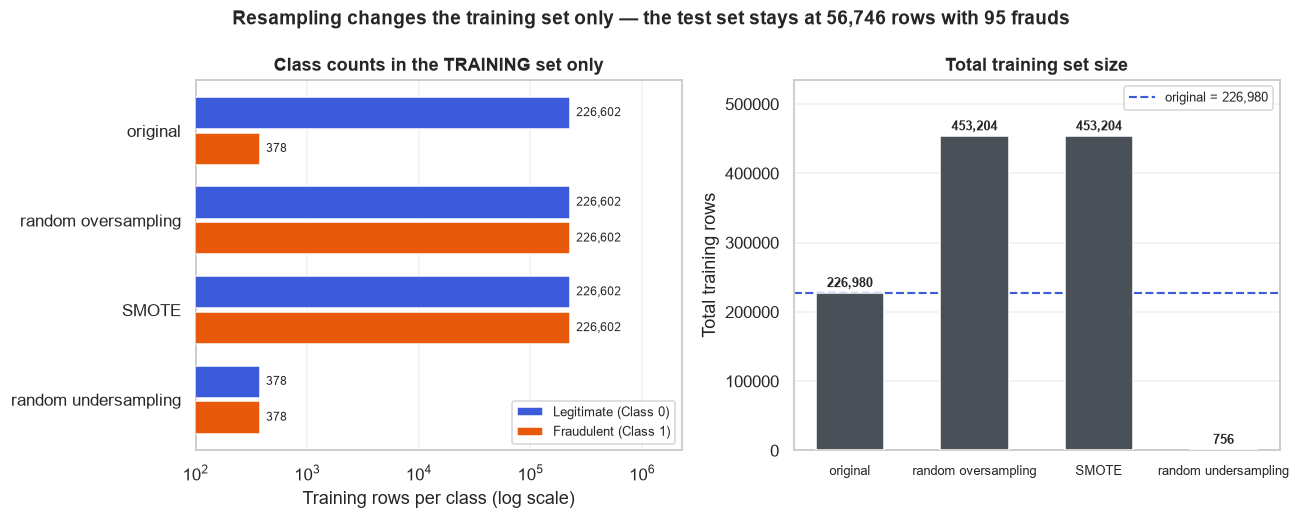

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

labels = list(resampling_table.index)
short_labels = [lbl.split(" - ")[1].replace(" (no resampling)", "") for lbl in labels]
legit = resampling_table["class 0"].to_numpy()
fraud = resampling_table["class 1"].to_numpy()
y_pos = np.arange(len(labels))

axes[0].barh(y_pos - 0.2, legit, height=0.36, color=C_LEGIT, zorder=3, label=CLASS_LABELS[0])
axes[0].barh(y_pos + 0.2, fraud, height=0.36, color=C_FRAUD, zorder=3, label=CLASS_LABELS[1])
axes[0].set_xscale("log")
axes[0].set_yticks(y_pos, short_labels)
axes[0].invert_yaxis()
axes[0].set_xlabel("Training rows per class (log scale)")
axes[0].set_title("Class counts in the TRAINING set only")
axes[0].legend(frameon=True, loc="lower right", fontsize=8.5)
axes[0].set_xlim(100, legit.max() * 10)
for i, (l, f) in enumerate(zip(legit, fraud)):
    axes[0].annotate(f"{l:,}", xy=(l, i - 0.2), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8)
    axes[0].annotate(f"{f:,}", xy=(f, i + 0.2), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8)
axes[0].grid(axis="y", visible=False)

totals = resampling_table["training rows"].to_numpy()
bars = axes[1].bar(np.arange(len(labels)), totals, color=C_NEUTRAL, width=0.55, zorder=3)
axes[1].set_xticks(np.arange(len(labels)), short_labels, rotation=0, fontsize=8.5)
axes[1].set_ylabel("Total training rows")
axes[1].set_title("Total training set size")
axes[1].axhline(len(y_train), color=C_LEGIT, linestyle="--", linewidth=1.4,
                label=f"original = {len(y_train):,}")
axes[1].legend(frameon=True, fontsize=8.5)
for bar, total in zip(bars, totals):
    axes[1].annotate(f"{total:,}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8.5,
                     fontweight="bold")
axes[1].set_ylim(0, totals.max() * 1.18)
axes[1].grid(axis="x", visible=False)

fig.suptitle(f"Resampling changes the training set only — the test set stays at "
             f"{len(y_test):,} rows with {int(test_counts_after[1])} frauds",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "10_resampling_comparison.png")
plt.show()

---
## 12. Preprocessing Validation

### Visualisation 9 — before and after scaling

`Time` and `Amount` are shown because they are the two columns that forced scaling, alongside one
component (`V1`) for contrast. The y-axes differ by orders of magnitude before scaling and share
one after — which is the entire point of the step.

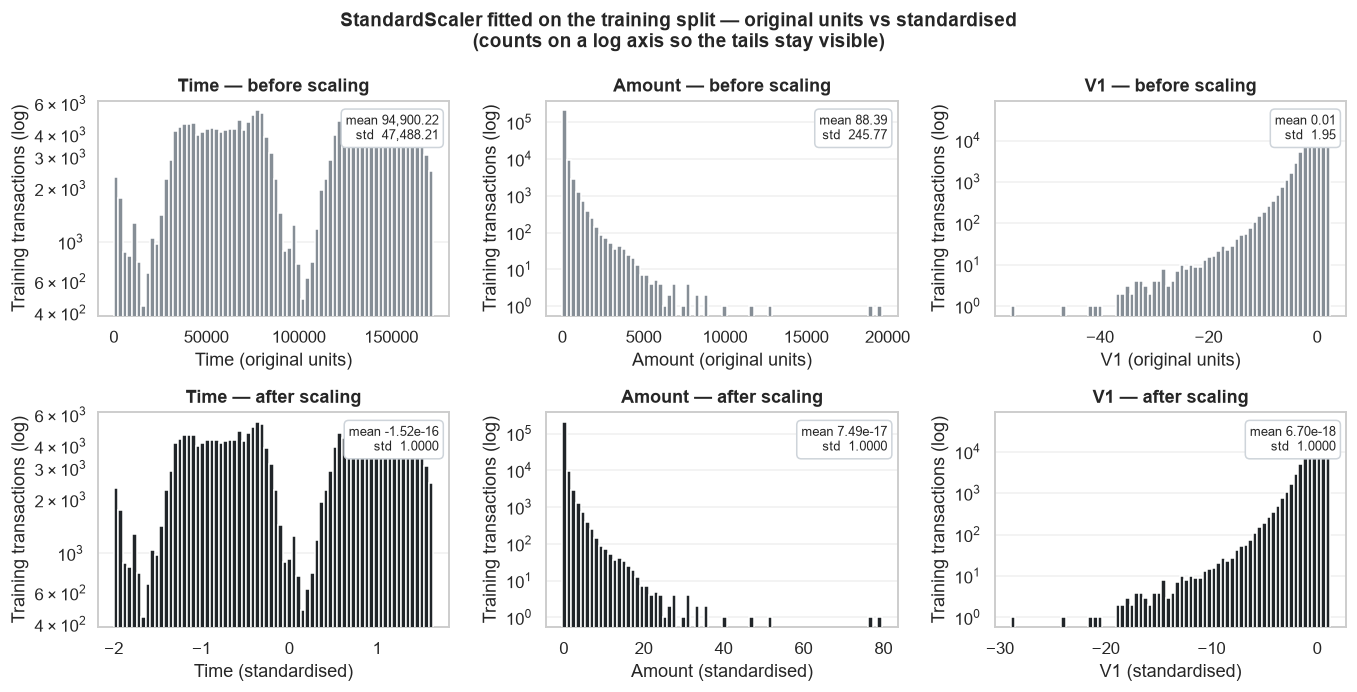

In [26]:
show_features = ["Time", "Amount", "V1"]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4))

for col, feature in enumerate(show_features):
    raw_values = X_train[feature]
    scaled_values = train_t_df[feature]

    axes[0, col].hist(raw_values, bins=70, color=C_BEFORE, zorder=3)
    axes[0, col].set_title(f"{feature} — before scaling")
    axes[0, col].set_xlabel(f"{feature} (original units)")
    axes[0, col].set_ylabel("Training transactions")
    axes[0, col].annotate(f"mean {raw_values.mean():,.2f}\nstd  {raw_values.std():,.2f}",
                          xy=(0.97, 0.94), xycoords="axes fraction", ha="right", va="top",
                          fontsize=8.5, bbox=dict(boxstyle="round,pad=0.35", fc="white",
                                                  ec="#ced4da"))

    axes[1, col].hist(scaled_values, bins=70, color=C_AFTER, zorder=3)
    axes[1, col].set_title(f"{feature} — after scaling")
    axes[1, col].set_xlabel(f"{feature} (standardised)")
    axes[1, col].set_ylabel("Training transactions")
    axes[1, col].annotate(f"mean {scaled_values.mean():,.2e}\nstd  {scaled_values.std():,.4f}",
                          xy=(0.97, 0.94), xycoords="axes fraction", ha="right", va="top",
                          fontsize=8.5, bbox=dict(boxstyle="round,pad=0.35", fc="white",
                                                  ec="#ced4da"))

for ax in axes.ravel():
    ax.grid(axis="x", visible=False)
    ax.set_yscale("log")           # the tails are what matter here; a linear count axis hides them
    ax.set_ylabel("Training transactions (log)")

fig.suptitle("StandardScaler fitted on the training split — original units vs standardised\n"
             "(counts on a log axis so the tails stay visible)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "09_scaling_comparison.png")
plt.show()

Note the shapes are **unchanged** — scaling shifts and rescales an axis, it does not make a skewed
distribution symmetric. `Amount` is as right-skewed after standardisation as before. That is
exactly why `"log_amount"` exists as a Phase 3 candidate.

### 12.1 Automated validation suite

Every check below returns a boolean. A failure is reported as `FAIL` and the phase summary marks
the phase failed; nothing is hidden.

In [27]:
validation_checks = []
validation_checks += dp.validate_split(split, df)
validation_checks += dp.validate_preprocessor(preprocessor, split, X_train_t, X_test_t)
validation_checks += dp.validate_resampling(
    y_train_original=y_train,
    y_train_resampled=resampled_targets["D - SMOTE"],
    y_test_before=y_test_before,
    y_test_after=y_test,
)

# Additional checks specific to this notebook's state.
validation_checks += [
    ("raw CSV still has all 284,807 rows", len(df_raw) == dp.EXPECTED_RAW_ROWS),
    ("deduplicated frame has 283,726 rows", len(df) == dp.EXPECTED_DEDUPLICATED_ROWS),
    ("no duplicate rows remain after deduplication", int(df.duplicated().sum()) == 0),
    ("output feature names are unique", len(set(feature_names_out)) == len(feature_names_out)),
    ("test set row count unchanged end to end", len(X_test) == n_test_before),
]

validation = pd.DataFrame(validation_checks, columns=["check", "passed"])
validation["status"] = np.where(validation["passed"], "PASS", "FAIL")
validation[["check", "status"]]

,check,status
0,X and y row counts match in train,PASS
1,X and y row counts match in test,PASS
2,target has exactly two classes,PASS
3,train + test equals the full row count,PASS
4,test size matches the requested fraction,PASS
5,train contains both classes,PASS
6,test contains both classes,PASS
7,train fraud rate within 0.05 pp of the full da...,PASS
8,test fraud rate within 0.05 pp of the full dat...,PASS
9,no row index appears in both splits,PASS


### 12.2 Module tests

The preprocessing module is exercised directly, including the paths that are *supposed* to fail.
A module that silently accepts a malformed frame is worse than one that raises.

In [28]:
module_tests = []


def record(name, fn):
    """Run a test, record pass/fail, and never let a failure go unreported."""
    try:
        fn()
        module_tests.append((name, True, ""))
    except Exception as exc:  # noqa: BLE001 - a failed test must be reported, not raised
        module_tests.append((name, False, f"{type(exc).__name__}: {exc}"))


def expect_raises(exc_type, fn):
    """Invert the test: passing means the function raised the expected error."""
    def wrapped():
        try:
            fn()
        except exc_type:
            return
        raise AssertionError(f"expected {exc_type.__name__}, but no error was raised")
    return wrapped


# --- valid paths ---------------------------------------------------------------------
def test_load_deduplicated():
    assert dp.load_data().shape == (dp.EXPECTED_DEDUPLICATED_ROWS, 31)


def test_load_raw():
    assert dp.load_data(drop_duplicates=False).shape == (dp.EXPECTED_RAW_ROWS, 31)


def test_target_excluded_from_features():
    X, y = dp.split_features_target(df)
    assert dp.TARGET_COLUMN not in X.columns
    assert len(X) == len(y)
    assert list(X.columns) == dp.FEATURE_COLUMNS


def test_split_is_deterministic():
    assert dp.split_data(df).X_train.index.equals(split.X_train.index)


record("load_data returns the deduplicated frame", test_load_deduplicated)
record("load_data(drop_duplicates=False) returns the raw frame", test_load_raw)
record("split_features_target keeps Class out of X", test_target_excluded_from_features)
record("split_data is deterministic for a fixed seed", test_split_is_deterministic)

for strategy in ("standard", "minimal", "log_amount"):
    def _fit_transform(s=strategy):
        pre = dp.build_preprocessor(s).fit(X_train)
        out_train = pre.transform(X_train)
        out_test = pre.transform(X_test)
        assert out_train.shape == (len(X_train), 30), f"{s}: bad train shape {out_train.shape}"
        assert out_test.shape == (len(X_test), 30), f"{s}: bad test shape {out_test.shape}"
        assert np.isfinite(out_train).all() and np.isfinite(out_test).all(), f"{s}: non-finite output"
    record(f"build_preprocessor('{strategy}') fits and transforms cleanly", _fit_transform)

for strategy in ("none", "class_weight", "oversample", "smote", "undersample"):
    def _build(s=strategy):
        sampler = dp.build_resampler(s, random_state=dp.RANDOM_STATE)
        if s in ("none", "class_weight"):
            assert sampler is None, f"{s} should not resample"
        else:
            assert hasattr(sampler, "fit_resample"), f"{s} is not a sampler"
    record(f"build_resampler('{strategy}') returns the right object", _build)

# --- failure paths: these must raise ------------------------------------------------
record("unknown scaling strategy raises",
       expect_raises(ValueError, lambda: dp.build_preprocessor("not_a_strategy")))
record("unknown resampling strategy raises",
       expect_raises(ValueError, lambda: dp.build_resampler("not_a_strategy")))
record("missing dataset file raises",
       expect_raises(FileNotFoundError,
                     lambda: dp.verify_raw_dataset_integrity(PROJECT_DIR / "dataset" / "nope.csv")))
record("a frame with a missing column is rejected",
       expect_raises(ValueError, lambda: dp.validate_raw_dataframe(df_raw.drop(columns=["V1"]))))
record("a frame with a renamed target is rejected",
       expect_raises(ValueError,
                     lambda: dp.validate_raw_dataframe(df_raw.rename(columns={"Class": "label"}))))
record("a frame containing NaN is rejected",
       expect_raises(ValueError, lambda: dp.validate_raw_dataframe(
           df_raw.head(dp.EXPECTED_RAW_ROWS).assign(Amount=lambda d: d["Amount"].mask(d.index < 5)))))
record("a frame containing infinity is rejected",
       expect_raises(ValueError, lambda: dp.validate_raw_dataframe(
           df_raw.assign(Amount=lambda d: d["Amount"].mask(d.index < 5, np.inf)))))
record("a frame with the wrong row count is rejected",
       expect_raises(ValueError, lambda: dp.validate_raw_dataframe(df_raw.head(1000))))

module_test_table = pd.DataFrame(module_tests, columns=["test", "passed", "error"])
module_test_table["status"] = np.where(module_test_table["passed"], "PASS", "FAIL")

n_module_passed = int(module_test_table["passed"].sum())
print(f"module tests: {n_module_passed} / {len(module_test_table)} passed")
if n_module_passed < len(module_test_table):
    print()
    print("FAILURES:")
    print(module_test_table.loc[~module_test_table["passed"], ["test", "error"]].to_string(index=False))
module_test_table[["test", "status"]]

module tests: 20 / 20 passed


,test,status
0,load_data returns the deduplicated frame,PASS
1,load_data(drop_duplicates=False) returns the r...,PASS
2,split_features_target keeps Class out of X,PASS
3,split_data is deterministic for a fixed seed,PASS
4,build_preprocessor('standard') fits and transf...,PASS
5,build_preprocessor('minimal') fits and transfo...,PASS
6,build_preprocessor('log_amount') fits and tran...,PASS
7,build_resampler('none') returns the right object,PASS
8,build_resampler('class_weight') returns the ri...,PASS
9,build_resampler('oversample') returns the righ...,PASS


---
## 13. Leakage Checks

The seven explicit tests, each backed by a computation rather than an assurance.

In [29]:
# 1 & 2 - the scaler must have seen exactly the training rows, and its statistics must differ
#         from full-dataset statistics (if they matched, it saw everything).
from sklearn.preprocessing import StandardScaler

fitted_scaler = preprocessor.named_transformers_["scale_all"]
scaler_on_everything = StandardScaler().fit(X_all)

n_seen = int(np.max(fitted_scaler.n_samples_seen_))

print(f"scaler.n_samples_seen_ : {n_seen:,}")
print(f"len(X_train)           : {len(X_train):,}")
print(f"len(X_test)            : {len(X_test):,}")
print(f"len(full dataset)      : {len(X_all):,}")
print()
print("scaler saw exactly the training rows :", n_seen == len(X_train))
print("scaler did NOT see the full dataset  :", n_seen != len(X_all))
print()
print("learned statistics, train-fitted vs full-dataset-fitted:")
print(f"{'feature':>8} {'train mean':>15} {'full mean':>15} {'train scale':>14} {'full scale':>14}")
for feature in ("Time", "Amount", "V1", "V28"):
    i = dp.FEATURE_COLUMNS.index(feature)
    print(f"{feature:>8} {fitted_scaler.mean_[i]:>15.6f} {scaler_on_everything.mean_[i]:>15.6f} "
          f"{fitted_scaler.scale_[i]:>14.6f} {scaler_on_everything.scale_[i]:>14.6f}")
print()
statistics_differ = not np.allclose(fitted_scaler.mean_, scaler_on_everything.mean_)
print("statistics differ from a full-dataset fit:", statistics_differ)
print("(identical statistics would mean the test rows had been included in the fit)")

scaler.n_samples_seen_ : 226,980


len(X_train)           : 226,980
len(X_test)            : 56,746
len(full dataset)      : 283,726

scaler saw exactly the training rows : True
scaler did NOT see the full dataset  : True

learned statistics, train-fitted vs full-dataset-fitted:
 feature      train mean       full mean    train scale     full scale
    Time    94900.224390    94811.077600   47488.109673   47480.964216
  Amount       88.387124       88.472687     245.766505     250.398996
      V1        0.005027        0.005917       1.947289       1.948023
     V28        0.000948        0.000547       0.325748       0.328026

statistics differ from a full-dataset fit: True
(identical statistics would mean the test rows had been included in the fit)


In [30]:
# 3 - resampling saw training data only.
smote_sampler = dp.build_resampler("smote", random_state=dp.RANDOM_STATE)
X_smote, y_smote = smote_sampler.fit_resample(X_train, y_train)

print(f"rows fed to SMOTE      : {len(X_train):,}  (= len(X_train))")
print(f"rows produced by SMOTE : {len(X_smote):,}")
print(f"test rows fed to SMOTE : 0")
print()

# 7 - no synthetic sample can be in the test set: the test frame is the identical object
#     produced by the split, with its original index.
print("test index is unchanged since the split :", X_test.index.equals(split.X_test.index))
print("test values are unchanged since the split:", X_test.equals(split.X_test))
print()

# 4 - test class counts identical before and after everything above.
print("test class counts before :", test_counts_before.to_dict())
print("test class counts after  :", y_test.value_counts().sort_index().to_dict())
print("identical                :", test_counts_before.equals(y_test.value_counts().sort_index()))

rows fed to SMOTE      : 226,980  (= len(X_train))
rows produced by SMOTE : 453,204
test rows fed to SMOTE : 0

test index is unchanged since the split : True
test values are unchanged since the split: True

test class counts before : {0: 56651, 1: 95}
test class counts after  : {0: 56651, 1: 95}
identical                : True


In [31]:
# 5 & 6 - the target never enters the feature matrix, and no feature is derived from it.
target_in_features = dp.TARGET_COLUMN in X_train.columns or dp.TARGET_COLUMN in X_test.columns
features_are_original = list(X_train.columns) == dp.FEATURE_COLUMNS
no_new_features = len(feature_names_out) == len(dp.FEATURE_COLUMNS)

# A feature derived from the target would correlate with it far more strongly than Phase 1's
# strongest marginal association (|r| = 0.3265 for V17). Re-checked on the training split.
train_corr = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True)[dp.TARGET_COLUMN]
train_corr = train_corr.drop(dp.TARGET_COLUMN)

print("target column present in X          :", target_in_features)
print("feature list is the original 30     :", features_are_original)
print("no feature added by preprocessing   :", no_new_features)
print()
print(f"strongest |correlation| with Class on the training split: {train_corr.abs().max():.4f} "
      f"({train_corr.abs().idxmax()})")
print("below the 0.95 threshold that would signal a target-derived feature:",
      bool(train_corr.abs().max() < 0.95))

target column present in X          : False
feature list is the original 30     : True
no feature added by preprocessing   : True

strongest |correlation| with Class on the training split: 0.3207 (V17)
below the 0.95 threshold that would signal a target-derived feature: True


In [32]:
leakage_checks = [
    ("1. scaler fitted on training rows only", n_seen == len(X_train)),
    ("2. test rows never used to compute scaling statistics",
     n_seen != len(X_all) and statistics_differ),
    ("3. resampling saw training data only", len(X_smote) >= len(X_train) and len(X_train) == split.n_train),
    ("4. test class counts identical before and after preprocessing",
     test_counts_before.equals(y_test.value_counts().sort_index())),
    ("5. no target column in the feature matrix", not target_in_features),
    ("6. no target-derived feature created",
     features_are_original and no_new_features and bool(train_corr.abs().max() < 0.95)),
    ("7. no synthetic sample in the test set", X_test.equals(split.X_test)),
]

leakage = pd.DataFrame(leakage_checks, columns=["leakage test", "passed"])
leakage["status"] = np.where(leakage["passed"], "PASS", "FAIL")

# Fail loudly. If any leakage test fails, the phase is not complete.
assert leakage["passed"].all(), (
    "LEAKAGE TEST FAILED:\n"
    + leakage.loc[~leakage["passed"], "leakage test"].to_string(index=False)
)

print(f"leakage tests passed: {int(leakage['passed'].sum())} / {len(leakage)}")
leakage[["leakage test", "status"]]

leakage tests passed: 7 / 7


,leakage test,status
0,1. scaler fitted on training rows only,PASS
1,2. test rows never used to compute scaling sta...,PASS
2,3. resampling saw training data only,PASS
3,4. test class counts identical before and afte...,PASS
4,5. no target column in the feature matrix,PASS
5,6. no target-derived feature created,PASS
6,7. no synthetic sample in the test set,PASS


---
## 14. Reproducibility and Raw-Data Integrity

### 14.1 Determinism

Every randomised operation in this phase takes `random_state=42`: the train/test split, SMOTE,
`RandomOverSampler` and `RandomUnderSampler`. The check below re-runs each from scratch and
confirms it lands in the same place.

In [33]:
split_again = dp.split_data(df, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)

determinism_checks = [
    ("train index identical on a re-run", split_again.X_train.index.equals(split.X_train.index)),
    ("test index identical on a re-run", split_again.X_test.index.equals(split.X_test.index)),
]

for strategy in ("oversample", "smote", "undersample"):
    first = dp.build_resampler(strategy, random_state=dp.RANDOM_STATE).fit_resample(X_train, y_train)
    second = dp.build_resampler(strategy, random_state=dp.RANDOM_STATE).fit_resample(X_train, y_train)
    determinism_checks.append(
        (f"{strategy} produces identical output on a re-run",
         np.array_equal(np.asarray(first[0]), np.asarray(second[0]))
         and np.array_equal(np.asarray(first[1]), np.asarray(second[1])))
    )

pre_again = dp.build_preprocessor("standard").fit(X_train)
determinism_checks.append(
    ("preprocessor learns identical statistics on a re-run",
     np.allclose(pre_again.named_transformers_["scale_all"].mean_, fitted_scaler.mean_)
     and np.allclose(pre_again.named_transformers_["scale_all"].scale_, fitted_scaler.scale_))
)

determinism = pd.DataFrame(determinism_checks, columns=["check", "passed"])
determinism["status"] = np.where(determinism["passed"], "PASS", "FAIL")
determinism[["check", "status"]]

,check,status
0,train index identical on a re-run,PASS
1,test index identical on a re-run,PASS
2,oversample produces identical output on a re-run,PASS
3,smote produces identical output on a re-run,PASS
4,undersample produces identical output on a re-run,PASS
5,preprocessor learns identical statistics on a ...,PASS


### 14.2 Raw-data integrity

The digest is recomputed after every operation above. If it differs from section 2's value, this
phase modified the raw data and has failed.

In [34]:
SHA256_FINAL = dp.sha256_of_file(DATASET_PATH)

print("SHA-256 initial:", SHA256_INITIAL)
print("SHA-256 final  :", SHA256_FINAL)
print("raw data status:", "UNCHANGED" if SHA256_FINAL == SHA256_INITIAL else "*** MODIFIED ***")
print()
print("file size unchanged :", DATASET_PATH.stat().st_size == FILE_SIZE_BYTES)
print("matches Phase 1     :", SHA256_FINAL == dp.RAW_DATASET_SHA256)

integrity_checks = [
    ("raw CSV size unchanged", DATASET_PATH.stat().st_size == FILE_SIZE_BYTES),
    ("raw CSV SHA-256 unchanged within this phase", SHA256_FINAL == SHA256_INITIAL),
    ("raw CSV SHA-256 still matches Phase 1", SHA256_FINAL == dp.RAW_DATASET_SHA256),
]

SHA-256 initial: 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
SHA-256 final  : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
raw data status: UNCHANGED

file size unchanged : True
matches Phase 1     : True


### 14.3 Visualisation inventory

In [35]:
expected_figures = {
    "08_train_test_class_distribution.png":
        "Class distribution across full dataset, train and test - stratification is preserved",
    "09_scaling_comparison.png":
        "Time, Amount and V1 before and after StandardScaler fitted on the training split",
    "10_resampling_comparison.png":
        "Training-set class counts and totals under original / oversampling / SMOTE / undersampling",
}

inventory = []
for filename, purpose in expected_figures.items():
    path = VIZ_DIR / filename
    inventory.append({
        "file": filename,
        "exists": path.is_file(),
        "KiB": round(path.stat().st_size / 1024, 1) if path.is_file() else 0,
        "purpose": purpose,
    })

inventory_df = pd.DataFrame(inventory).set_index("file")
print("all Phase 2 figures written:", bool(inventory_df["exists"].all()))
inventory_df

all Phase 2 figures written: True


,exists,KiB,purpose
file,,,
08_train_test_class_distribution.png,True,85.6000,"Class distribution across full dataset, train ..."
09_scaling_comparison.png,True,172.0000,"Time, Amount and V1 before and after StandardS..."
10_resampling_comparison.png,True,84.0000,Training-set class counts and totals under ori...


---
## 15. Phase 2 Findings

**Dataset.** Loaded from `dataset/creditcard.csv`, checksum verified against the Phase 1 value
before reading. 284,807 raw rows × 31 columns, all numeric, zero missing, zero infinities.

**Duplicates — the decision Phase 1 deferred.** The 1,081 exact duplicate rows (1,062 legitimate,
19 fraudulent) are **dropped before the split**, leaving **283,726 rows**: 283,253 legitimate and
473 fraudulent, a **598.84:1** imbalance. The cost is 19 fraud examples and a slightly harder
problem; the benefit is that no row can appear on both sides of the split, so the test score
cannot be partly a measurement of memorisation.

**Split.** Stratified 80/20, `random_state=42`:

| | Rows | Legitimate | Fraudulent | Fraud % | Ratio |
|---|---|---|---|---|---|
| Full (deduplicated) | 283,726 | 283,253 | 473 | 0.166710% | 598.84:1 |
| **Train** | **226,980** | 226,602 | **378** | 0.166534% | 599.48:1 |
| **Test** | **56,746** | 56,651 | **95** | 0.167413% | 596.33:1 |

Both splits sit within 0.001 pp of the full-dataset fraud rate. Unstratified draws of the same
data were shown to swing the test fraud count substantially from seed to seed — noise that would
have moved recall for reasons unrelated to the model.

**Scaling.** Measured on the training split, `Time` spans 1,534× the component range and `Amount`
175×; both must be scaled, and that is not a judgement call. Whether to standardise `V1`–`V28` is one, and it is left open with both options
implemented: `"standard"` (all 30, the default), `"minimal"` (`Time`/`Amount` only), and
`"log_amount"` (`log1p(Amount)` first, addressing its 16.98 skewness). The empirical choice is
deferred to a Phase 3 cross-validated comparison **on the training split only**.

**Pipeline.** `src/data_preprocessing.py` exposes `load_data`, `split_features_target`,
`split_data`, `build_preprocessor`, `build_resampler` and three validators. Fitted on 226,980
training rows; 30 features in, 30 out; no NaN or infinity introduced.

**Imbalance framework.** Five strategies documented; three that change rows were measured on the
training split only:

| Strategy | Training rows | Class 0 | Class 1 | Minority % |
|---|---|---|---|---|
| A — original | 226,980 | 226,602 | 378 | 0.1665% |
| B — class weights | 226,980 | 226,602 | 378 | 0.1665% (reweights the loss, not the rows) |
| C — random oversampling | 453,204 | 226,602 | 226,602 | 50.00% |
| D — SMOTE | 453,204 | 226,602 | 226,602 | 50.00% |
| E — random undersampling | 756 | 378 | 378 | 50.00% |

**None of these is judged here.** All three produce a 50/50 training set, which is a property of
the input and not evidence of quality. Undersampling reaches balance by discarding 226,224
legitimate transactions — 99.83% of the majority class.

**Leakage.** 7/7 explicit tests pass, each backed by a computation. The scaler saw exactly 226,980
samples and its learned statistics differ from a full-dataset fit (`Amount` scale 245.77 against
250.40), which is the positive evidence that the test rows were excluded. The test set came
through every operation with identical rows, identical class counts and no synthetic sample.

**Integrity.** The raw CSV's SHA-256 is unchanged, and still matches the Phase 1 value.

---
## 16. Phase 2 Conclusion

**What exists now.** A verified, deterministic, importable preprocessing foundation: a stratified
split that later phases can reproduce exactly, a scaling pipeline that cannot see the test set by
construction, and a resampling architecture that applies itself to training folds only.

**What deliberately does not exist.** No classifier, no metric, no model selection, no tuned
hyperparameter, no persisted artefact. The test set has not been scored and will not be until
Phase 5.

**Limitations of this phase.**

- The scaling choice between `"standard"`, `"minimal"` and `"log_amount"` is **unresolved**. It
  cannot be resolved without fitting a model, and resolving it by peeking at the test set would
  destroy the value of the split.
- Resampling was measured, not evaluated. Which strategy helps is a Phase 4 question.
- The 95 fraudulent transactions in the test set are a small sample. Recall estimated from them
  will carry real uncertainty, and Phase 5 should report that rather than quoting a point value
  as if it were precise.
- The deduplication decision removed 19 fraud rows. That is a deliberate, documented trade, not a
  cleaning side-effect.

**Next phase, for approval.** Phase 3 — baseline classifiers (logistic regression and random
forest, as the CodSoft brief names), compared by cross-validation on the training split, judged on
precision, recall, F1 and PR-AUC. The scaling-strategy comparison rides along with it. The test
set stays sealed.

In [36]:
all_validation_passed = bool(validation["passed"].all())
all_module_tests_passed = bool(module_test_table["passed"].all())
all_leakage_passed = bool(leakage["passed"].all())
all_determinism_passed = bool(determinism["passed"].all())
all_integrity_passed = all(passed for _, passed in integrity_checks)
all_figures_written = bool(inventory_df["exists"].all())

PHASE_2_OK = all([all_validation_passed, all_module_tests_passed, all_leakage_passed,
                  all_determinism_passed, all_integrity_passed, all_figures_written])

print("=" * 78)
print("PHASE 2 - PREPROCESSING & IMBALANCE FRAMEWORK - SUMMARY".center(78))
print("=" * 78)
print(f"{'raw dataset':<28}: {len(df_raw):,} rows x {df_raw.shape[1]} columns")
print(f"{'after deduplication':<28}: {len(df):,} rows  ({len(df_raw) - len(df):,} exact copies dropped)")
print(f"{'train':<28}: {split.n_train:,} rows  ({int((y_train == 1).sum())} fraud, "
      f"{(y_train == 1).mean() * 100:.6f}%)")
print(f"{'test':<28}: {split.n_test:,} rows   ({int((y_test == 1).sum())} fraud, "
      f"{(y_test == 1).mean() * 100:.6f}%)")
print(f"{'split':<28}: stratified 80/20, random_state={dp.RANDOM_STATE}")
print(f"{'scaling strategy (default)':<28}: standard - StandardScaler on all 30 features")
print(f"{'features in -> out':<28}: {len(dp.FEATURE_COLUMNS)} -> {len(feature_names_out)}")
print(f"{'scaler fitted on':<28}: {n_seen:,} rows (= training rows)")
print("-" * 78)
print(f"{'validation checks':<28}: {int(validation['passed'].sum())} / {len(validation)} passed")
print(f"{'module tests':<28}: {int(module_test_table['passed'].sum())} / {len(module_test_table)} passed")
print(f"{'leakage tests':<28}: {int(leakage['passed'].sum())} / {len(leakage)} passed")
print(f"{'determinism checks':<28}: {int(determinism['passed'].sum())} / {len(determinism)} passed")
print(f"{'integrity checks':<28}: {sum(p for _, p in integrity_checks)} / {len(integrity_checks)} passed")
print(f"{'figures written':<28}: {int(inventory_df['exists'].sum())} / {len(expected_figures)}")
print(f"{'raw data':<28}: {'UNCHANGED' if SHA256_FINAL == SHA256_INITIAL else 'MODIFIED'}")
print("-" * 78)
print("PHASE 2 STATUS:", "COMPLETE" if PHASE_2_OK else "FAILED")
print("No classifier trained. No metric computed. Test set not scored. Phase 3 not started.")
print("=" * 78)

           PHASE 2 - PREPROCESSING & IMBALANCE FRAMEWORK - SUMMARY            
raw dataset                 : 284,807 rows x 31 columns
after deduplication         : 283,726 rows  (1,081 exact copies dropped)
train                       : 226,980 rows  (378 fraud, 0.166534%)
test                        : 56,746 rows   (95 fraud, 0.167413%)
split                       : stratified 80/20, random_state=42
scaling strategy (default)  : standard - StandardScaler on all 30 features
features in -> out          : 30 -> 30
scaler fitted on            : 226,980 rows (= training rows)
------------------------------------------------------------------------------
validation checks           : 29 / 29 passed
module tests                : 20 / 20 passed
leakage tests               : 7 / 7 passed
determinism checks          : 6 / 6 passed
integrity checks            : 3 / 3 passed
figures written             : 3 / 3
raw data                    : UNCHANGED
----------------------------------------------